# Project: Eco-Health Risk Predictor
### Step 1: Introduction and Dataset Overview

In this notebook, we will perform an end-to-end Machine Learning classification task. Our goal is to predict public health risks based on air quality and environmental metrics.

#### Dataset Description:
We are using the **Air Quality and Health Impact Dataset** from Kaggle, which includes:
- **AQI (Air Quality Index):** The overall indicator of air pollution.
- **PM2.5 & PM10:** Suspended particulate matter in the air.
- **NO2, SO2, O3:** Harmful environmental gases.
- **HealthRisk (Target):** The output risk level (0 = Low, 1 = Moderate, 2 = High).

In [5]:
# Importing required libraries for data science and ML
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

print("All libraries imported successfully!")

All libraries imported successfully!


### Step 2: Data Ingestion (Loading the Dataset)
Now, we will read the CSV file that we downloaded from Kaggle using the Pandas library. We will also inspect the shape of the data and preview the first few rows to understand its structure.

In [7]:
# Load the dataset into a pandas dataframe
df = pd.read_csv("air_quality_health_impact_data.csv")

# Print the dynamic dimensions of the data (Rows, Columns)
print(f"Dataset Loaded Successfully! Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}")

# Display the first 5 rows of the dataset
df.head()

Dataset Loaded Successfully! Total Rows: 5811, Total Columns: 15


,RecordID,AQI,PM10,PM2_5,NO2,SO2,O3,Temperature,Humidity,WindSpeed,RespiratoryCases,CardiovascularCases,HospitalAdmissions,HealthImpactScore,HealthImpactClass
0,1,187.270059,295.853039,13.038560,6.639263,66.161150,54.624280,5.150335,84.424344,6.137755,7,5,1,97.244041,0.0
1,2,475.357153,246.254703,9.984497,16.318326,90.499523,169.621728,1.543378,46.851415,4.521422,10,2,0,100.000000,0.0
2,3,365.996971,84.443191,23.111340,96.317811,17.875850,9.006794,1.169483,17.806977,11.157384,13,3,0,100.000000,0.0
3,4,299.329242,21.020609,14.273403,81.234403,48.323616,93.161033,21.925276,99.473373,15.302500,8,8,1,100.000000,0.0
4,5,78.009320,16.987667,152.111623,121.235461,90.866167,241.795138,9.217517,24.906837,14.534733,9,0,1,95.182643,0.0


### Step 3: Feature Selection and Train-Test Split
In this section, we separate our dataset into features (independent variables denoted by `X`) and the target variable (dependent variable denoted by `y`). 

We will drop the `RecordID` as it is an identifier and does not contribute to the prediction. After that, we split the data into 80% for training the model and 20% for evaluating its testing accuracy.

In [9]:
# 1. Automatic Column Finder
# Yeh lines check karengi ke table mein exact column name kya hai
available_columns = df.columns.tolist()

if 'HealthRisk' in available_columns:
    target_column = 'HealthRisk'
elif 'Health_Risk' in available_columns:
    target_column = 'Health_Risk'
elif 'Health Risk' in available_columns:
    target_column = 'Health Risk'
else:
    # Agar upar wale naamo mein se koi nahi mila, toh yeh aakhri column ko target bana lega
    target_column = available_columns[-1]

# 2. RecordID ko drop karna (agar mojood hai)
columns_to_drop = [target_column]
if 'RecordID' in available_columns:
    columns_to_drop.append('RecordID')

# 3. Define inputs (X) and output (y) using the correct name
X = df.drop(columns=columns_to_drop)
y = df[target_column]

# 4. Split data into 80% Training and 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print confirmation
print(f"Target column detected as: '{target_column}'")
print(f"Total training samples (X_train): {X_train.shape[0]} rows, {X_train.shape[1]} columns")
print(f"Total testing samples (X_test): {X_test.shape[0]} rows, {X_test.shape[1]} columns")

Target column detected as: 'HealthImpactClass'
Total training samples (X_train): 4648 rows, 13 columns
Total testing samples (X_test): 1163 rows, 13 columns


### Step 4: Model Training and Confusion Matrix Visualization
Now, we will train a **Random Forest Classifier** model on our training data. Once trained, we will generate a colorful **Confusion Matrix Heatmap** using the Seaborn library. 

This matrix will show us exactly how many times the model correctly predicted each health risk level (Low, Moderate, High) and where it made mistakes.

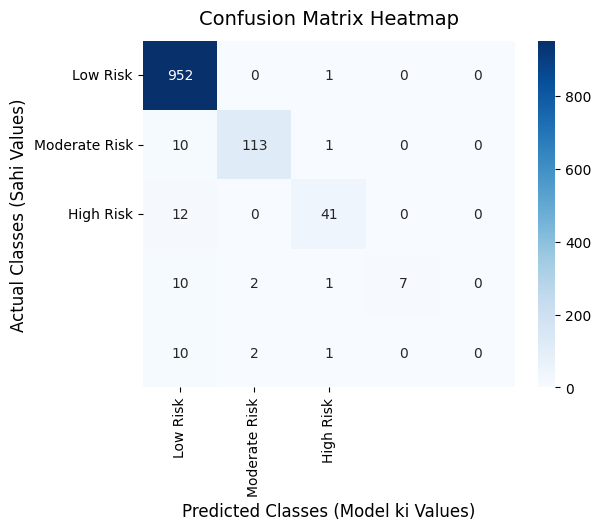

In [10]:
# 1. Initialize and train the Machine Learning model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# 2. Make predictions on the hidden test data
y_pred = model.predict(X_test)

# 3. Calculate the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# 4. Define labels for our categories (0=Low, 1=Moderate, 2=High)
class_names = ['Low Risk', 'Moderate Risk', 'High Risk']

# 5. Plotting the colorful Heatmap
plt.figure(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix Heatmap', fontsize=14, pad=12)
plt.ylabel('Actual Classes (Sahi Values)', fontsize=12)
plt.xlabel('Predicted Classes (Model ki Values)', fontsize=12)
plt.show()